In [1]:
#Import libraries
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
from google.colab import drive
import kagglehub
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

#Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded=files.upload()
vr=pd.read_excel('vr_training_sessions_15x12.xlsx')
vr

Saving vr_training_sessions_15x12.xlsx to vr_training_sessions_15x12.xlsx


,Participant_ID,Age,Gender,Session_Number,Date_Time,Environment,Phase,Task_Name,Task_Type,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,Therapist_Notes,Parental_Observation,Overall_Score,Progression_Status,Export_Format
0,P001,15,M,1,2025-01-10T09:46,Restaurant,Orientation,Order Food,Life Skills,1,1,111,2,12,29,NaN,NaN,76,Advance,Excel
1,P001,15,M,2,2025-01-13T10:07,Classroom,Orientation,Sit at Desk,Educational Skills,0,1,74,1,19,24,Task not mastered; repeat next session.,Observed calm participation.,56,Repeat,Excel
2,P001,15,M,3,2025-01-16T10:16,Restaurant,Training,Pay at Counter,Life Skills,1,2,135,4,10,16,High error rate; provide prompts.,NaN,57,Repeat,Excel
3,P001,15,M,4,2025-01-19T10:03,Classroom,Training,Raise Hand,Educational Skills,1,1,91,2,16,29,NaN,NaN,68,Advance,Excel
4,P001,15,M,5,2025-01-22T09:51,Restaurant,Training,Order Food,Life Skills,1,2,144,2,14,25,NaN,NaN,59,Advance,Excel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,P015,18,M,8,2025-02-03T10:02,Classroom,Training,Submit Worksheet,Educational Skills,1,2,96,2,12,27,NaN,NaN,66,Advance,Excel
176,P015,18,M,9,2025-02-06T09:45,Integrated,Integrated,Multi-Task Sequence,Mixed,1,2,93,3,20,24,High error rate; provide prompts.,NaN,61,Continue,Excel
177,P015,18,M,10,2025-02-09T09:52,Integrated,Integrated,Multi-Task Sequence,Mixed,1,3,128,3,15,32,High error rate; provide prompts.,NaN,59,Continue,Excel
178,P015,18,M,11,2025-02-12T09:34,Integrated,Integrated,Multi-Task Sequence,Mixed,0,2,102,2,11,33,Task not mastered; repeat next session.,NaN,53,Continue,Excel


In [3]:
vr.describe()

,Age,Session_Number,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,Overall_Score
count,180.00000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,17.20000,6.500000,0.705556,1.688889,116.638889,1.794444,14.327778,24.722222,64.972222
std,1.33035,3.461682,0.457064,0.654071,40.195022,1.017705,6.806036,8.791219,11.619397
min,15.00000,1.000000,0.000000,1.000000,20.000000,0.000000,1.000000,3.000000,39.000000
25%,16.00000,3.750000,0.000000,1.000000,92.000000,1.000000,10.000000,19.000000,57.000000
50%,18.00000,6.500000,1.000000,2.000000,117.000000,2.000000,14.000000,24.500000,65.000000
75%,18.00000,9.250000,1.000000,2.000000,143.250000,2.000000,19.000000,30.000000,73.000000
max,19.00000,12.000000,1.000000,3.000000,215.000000,4.000000,32.000000,52.000000,99.000000


In [4]:
vr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Participant_ID        180 non-null    object
 1   Age                   180 non-null    int64 
 2   Gender                180 non-null    object
 3   Session_Number        180 non-null    int64 
 4   Date_Time             180 non-null    object
 5   Environment           180 non-null    object
 6   Phase                 180 non-null    object
 7   Task_Name             180 non-null    object
 8   Task_Type             180 non-null    object
 9   Success               180 non-null    int64 
 10  Attempts              180 non-null    int64 
 11  Completion_Time       180 non-null    int64 
 12  Errors                180 non-null    int64 
 13  Navigation_Patterns   180 non-null    int64 
 14  Interaction_Count     180 non-null    int64 
 15  Therapist_Notes       108 non-null    ob

In [5]:
vr.isnull().sum()

,0
Participant_ID,0
Age,0
Gender,0
Session_Number,0
Date_Time,0
Environment,0
Phase,0
Task_Name,0
Task_Type,0
Success,0


In [6]:
vr.drop('Therapist_Notes', axis=1, inplace=True)
vr.drop('Parental_Observation', axis=1, inplace=True)
vr.drop('Export_Format', axis=1, inplace=True)
vr.drop('Date_Time', axis=1, inplace=True)

In [7]:
vr.drop('Participant_ID', axis=1, inplace=True)

In [8]:
vr.isnull().sum()

,0
Age,0
Gender,0
Session_Number,0
Environment,0
Phase,0
Task_Name,0
Task_Type,0
Success,0
Attempts,0
Completion_Time,0


In [9]:
vr

,Age,Gender,Session_Number,Environment,Phase,Task_Name,Task_Type,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,Overall_Score,Progression_Status
0,15,M,1,Restaurant,Orientation,Order Food,Life Skills,1,1,111,2,12,29,76,Advance
1,15,M,2,Classroom,Orientation,Sit at Desk,Educational Skills,0,1,74,1,19,24,56,Repeat
2,15,M,3,Restaurant,Training,Pay at Counter,Life Skills,1,2,135,4,10,16,57,Repeat
3,15,M,4,Classroom,Training,Raise Hand,Educational Skills,1,1,91,2,16,29,68,Advance
4,15,M,5,Restaurant,Training,Order Food,Life Skills,1,2,144,2,14,25,59,Advance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,18,M,8,Classroom,Training,Submit Worksheet,Educational Skills,1,2,96,2,12,27,66,Advance
176,18,M,9,Integrated,Integrated,Multi-Task Sequence,Mixed,1,2,93,3,20,24,61,Continue
177,18,M,10,Integrated,Integrated,Multi-Task Sequence,Mixed,1,3,128,3,15,32,59,Continue
178,18,M,11,Integrated,Integrated,Multi-Task Sequence,Mixed,0,2,102,2,11,33,53,Continue


In [10]:
Gender_encoder = LabelEncoder()
vr['Gender'] = Gender_encoder.fit_transform(vr['Gender'])
vr.head()

,Age,Gender,Session_Number,Environment,Phase,Task_Name,Task_Type,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,Overall_Score,Progression_Status
0,15,1,1,Restaurant,Orientation,Order Food,Life Skills,1,1,111,2,12,29,76,Advance
1,15,1,2,Classroom,Orientation,Sit at Desk,Educational Skills,0,1,74,1,19,24,56,Repeat
2,15,1,3,Restaurant,Training,Pay at Counter,Life Skills,1,2,135,4,10,16,57,Repeat
3,15,1,4,Classroom,Training,Raise Hand,Educational Skills,1,1,91,2,16,29,68,Advance
4,15,1,5,Restaurant,Training,Order Food,Life Skills,1,2,144,2,14,25,59,Advance


In [11]:
ordinal_encoder = OrdinalEncoder()
vr['Phase'] = ordinal_encoder.fit_transform(vr[['Phase']])
vr.head()

,Age,Gender,Session_Number,Environment,Phase,Task_Name,Task_Type,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,Overall_Score,Progression_Status
0,15,1,1,Restaurant,2.0,Order Food,Life Skills,1,1,111,2,12,29,76,Advance
1,15,1,2,Classroom,2.0,Sit at Desk,Educational Skills,0,1,74,1,19,24,56,Repeat
2,15,1,3,Restaurant,3.0,Pay at Counter,Life Skills,1,2,135,4,10,16,57,Repeat
3,15,1,4,Classroom,3.0,Raise Hand,Educational Skills,1,1,91,2,16,29,68,Advance
4,15,1,5,Restaurant,3.0,Order Food,Life Skills,1,2,144,2,14,25,59,Advance


In [12]:
vr = pd.get_dummies(vr, columns=['Environment','Task_Type','Task_Name','Progression_Status'], drop_first=True)
vr.head()

,Age,Gender,Session_Number,Phase,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,...,Task_Name_Pay at Counter,Task_Name_Raise Hand,Task_Name_Sit at Desk,Task_Name_Submit Worksheet,Task_Name_Switch Environments,Task_Name_Use Utensils,Progression_Status_Complete,Progression_Status_Continue,Progression_Status_Repeat,Progression_Status_Review
0,15,1,1,2.0,1,1,111,2,12,29,...,False,False,False,False,False,False,False,False,False,False
1,15,1,2,2.0,0,1,74,1,19,24,...,False,False,True,False,False,False,False,False,True,False
2,15,1,3,3.0,1,2,135,4,10,16,...,True,False,False,False,False,False,False,False,True,False
3,15,1,4,3.0,1,1,91,2,16,29,...,False,True,False,False,False,False,False,False,False,False
4,15,1,5,3.0,1,2,144,2,14,25,...,False,False,False,False,False,False,False,False,False,False


In [13]:
numerical_feats = vr[['Age', 'Session_Number','Attempts','Completion_Time','Errors','Navigation_Patterns','Interaction_Count','Overall_Score']]

In [14]:
vr

,Age,Gender,Session_Number,Phase,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,...,Task_Name_Pay at Counter,Task_Name_Raise Hand,Task_Name_Sit at Desk,Task_Name_Submit Worksheet,Task_Name_Switch Environments,Task_Name_Use Utensils,Progression_Status_Complete,Progression_Status_Continue,Progression_Status_Repeat,Progression_Status_Review
0,15,1,1,2.0,1,1,111,2,12,29,...,False,False,False,False,False,False,False,False,False,False
1,15,1,2,2.0,0,1,74,1,19,24,...,False,False,True,False,False,False,False,False,True,False
2,15,1,3,3.0,1,2,135,4,10,16,...,True,False,False,False,False,False,False,False,True,False
3,15,1,4,3.0,1,1,91,2,16,29,...,False,True,False,False,False,False,False,False,False,False
4,15,1,5,3.0,1,2,144,2,14,25,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,18,1,8,3.0,1,2,96,2,12,27,...,False,False,False,True,False,False,False,False,False,False
176,18,1,9,1.0,1,2,93,3,20,24,...,False,False,False,False,False,False,False,True,False,False
177,18,1,10,1.0,1,3,128,3,15,32,...,False,False,False,False,False,False,False,True,False,False
178,18,1,11,1.0,0,2,102,2,11,33,...,False,False,False,False,False,False,False,True,False,False


<Axes: >

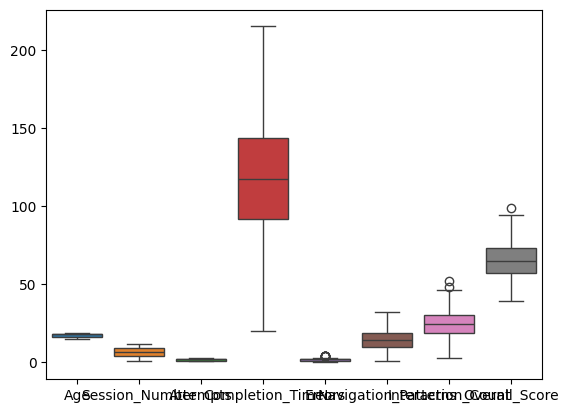

In [15]:
sns.boxplot(data=numerical_feats)

In [16]:
std_scaler = StandardScaler()
standardized_features = std_scaler.fit_transform(numerical_feats)

In [17]:
vr[['Age', 'Session_Number','Attempts','Completion_Time','Errors','Navigation_Patterns','Interaction_Count','Overall_Score']]=standardized_features

In [18]:
display(vr.head())

,Age,Gender,Session_Number,Phase,Success,Attempts,Completion_Time,Errors,Navigation_Patterns,Interaction_Count,...,Task_Name_Pay at Counter,Task_Name_Raise Hand,Task_Name_Sit at Desk,Task_Name_Submit Worksheet,Task_Name_Switch Environments,Task_Name_Use Utensils,Progression_Status_Complete,Progression_Status_Continue,Progression_Status_Repeat,Progression_Status_Review
0,-1.658312,1,-1.593255,2.0,1,-1.056171,-0.140680,0.202543,-0.342971,0.487954,...,False,False,False,False,False,False,False,False,False,False
1,-1.658312,1,-1.303572,2.0,0,-1.056171,-1.063759,-0.782801,0.688397,-0.082382,...,False,False,True,False,False,False,False,False,True,False
2,-1.658312,1,-1.013890,3.0,1,0.476980,0.458075,2.173231,-0.637647,-0.994919,...,True,False,False,False,False,False,False,False,True,False
3,-1.658312,1,-0.724207,3.0,1,-1.056171,-0.639642,0.202543,0.246382,0.487954,...,False,True,False,False,False,False,False,False,False,False
4,-1.658312,1,-0.434524,3.0,1,0.476980,0.682608,0.202543,-0.048294,0.031685,...,False,False,False,False,False,False,False,False,False,False


In [19]:
from sklearn.model_selection import train_test_split

X = vr.drop('Success', axis=1)
y = vr['Success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (144, 28)
Testing set shape: (36, 28)


In [20]:
vr['Success'].value_counts()

,count
Success,
1,127
0,53


In [21]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

In [22]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

svm_model = SVC()
svm_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

pa_model = PassiveAggressiveClassifier()
pa_model.fit(X_train, y_train)

per_model = Perceptron()
per_model.fit(X_train, y_train)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

ann_model = MLPClassifier()
ann_model.fit(X_train, y_train)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

Accuracy: 0.9722
Precision: 1.0000
Recall: 0.9630
F1-score: 0.9811


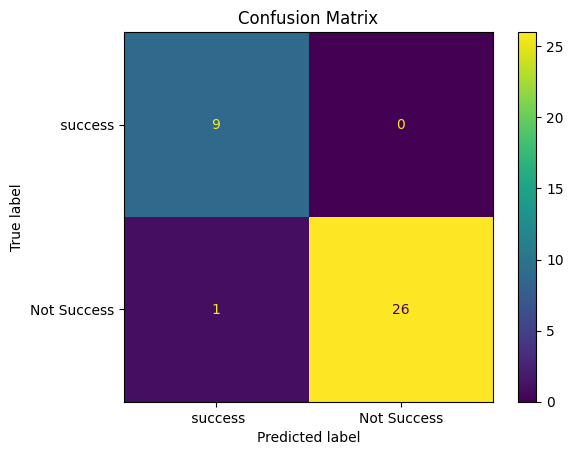

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = per_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=[' success', 'Not Success'])
cmd.plot()
plt.title('Confusion Matrix')
plt.show()

                          feature  importance
9                   Overall_Score    0.308909
26      Progression_Status_Repeat    0.154701
5                 Completion_Time    0.076319
6                          Errors    0.073292
8               Interaction_Count    0.072774
7             Navigation_Patterns    0.061887
2                  Session_Number    0.037492
0                             Age    0.035515
25    Progression_Status_Continue    0.025266
1                          Gender    0.021896
4                        Attempts    0.017667
3                           Phase    0.016779
19           Task_Name_Raise Hand    0.013080
16  Task_Name_Multi-Task Sequence    0.008720
17           Task_Name_Order Food    0.008471
15      Task_Name_Follow Schedule    0.007689
27      Progression_Status_Review    0.007349
13                Task_Type_Mixed    0.007286
11         Environment_Restaurant    0.006566
18       Task_Name_Pay at Counter    0.005972
22  Task_Name_Switch Environments 

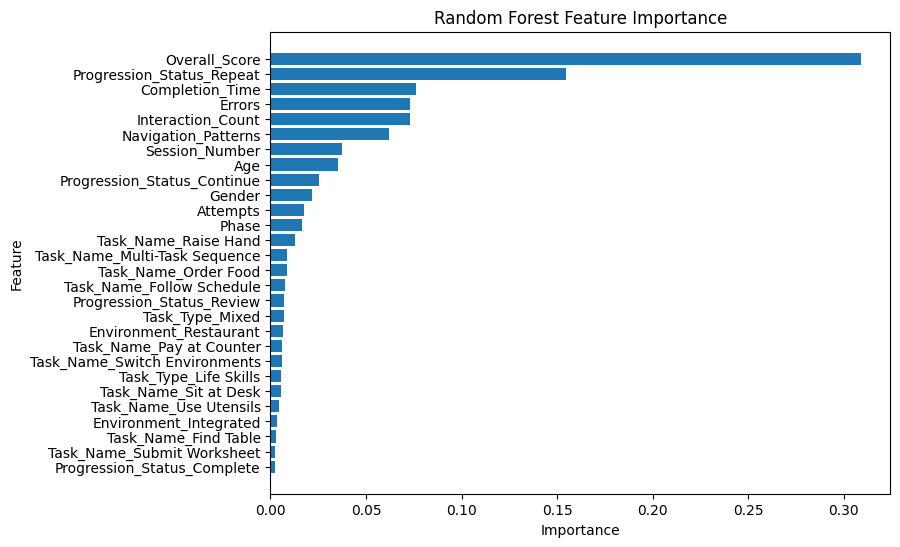

In [24]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()